In [1]:
import sys
sys.path.insert(0, "../lib")  # add lib path to search list
# IMPORTS
import stim
import numpy as np
from visulise_lattice import plot_surface_code
from mwpm import build_mwpm_decoder, measure_logical, exec_mwpm
from utils import *
# import pymatching
# import sinter
print(stim.__version__)

1.15.0


# Import Surface Code Circuit

In [2]:
surface_code_unrotated_z = stim.Circuit.from_file("/home/samir/research/experiments/surface_code_simulations/circuits/surface_code_unrotated_z.stim")
surface_code_unrotated_x = stim.Circuit.from_file("/home/samir/research/experiments/surface_code_simulations/circuits/surface_code_unrotated_x.stim")



surface_code = surface_code_unrotated_z

In [3]:
# surface_code = stim.Circuit.generated(
#     "surface_code:unrotated_memory_x",
#     distance=3,
#     rounds=10,
#     after_clifford_depolarization=0,
#     after_reset_flip_probability=0,
#     before_measure_flip_probability=0,
#     before_round_data_depolarization=0
# )



# # # surface_code.insert(27, stim.CircuitInstruction("Z_ERROR(1) 20"))
# # # surface_code.append("TICK")
# # # surface_code.append("Z_ERROR", [20], 1)
# # # surface_code.append("TICK")
# # print((surface_code))


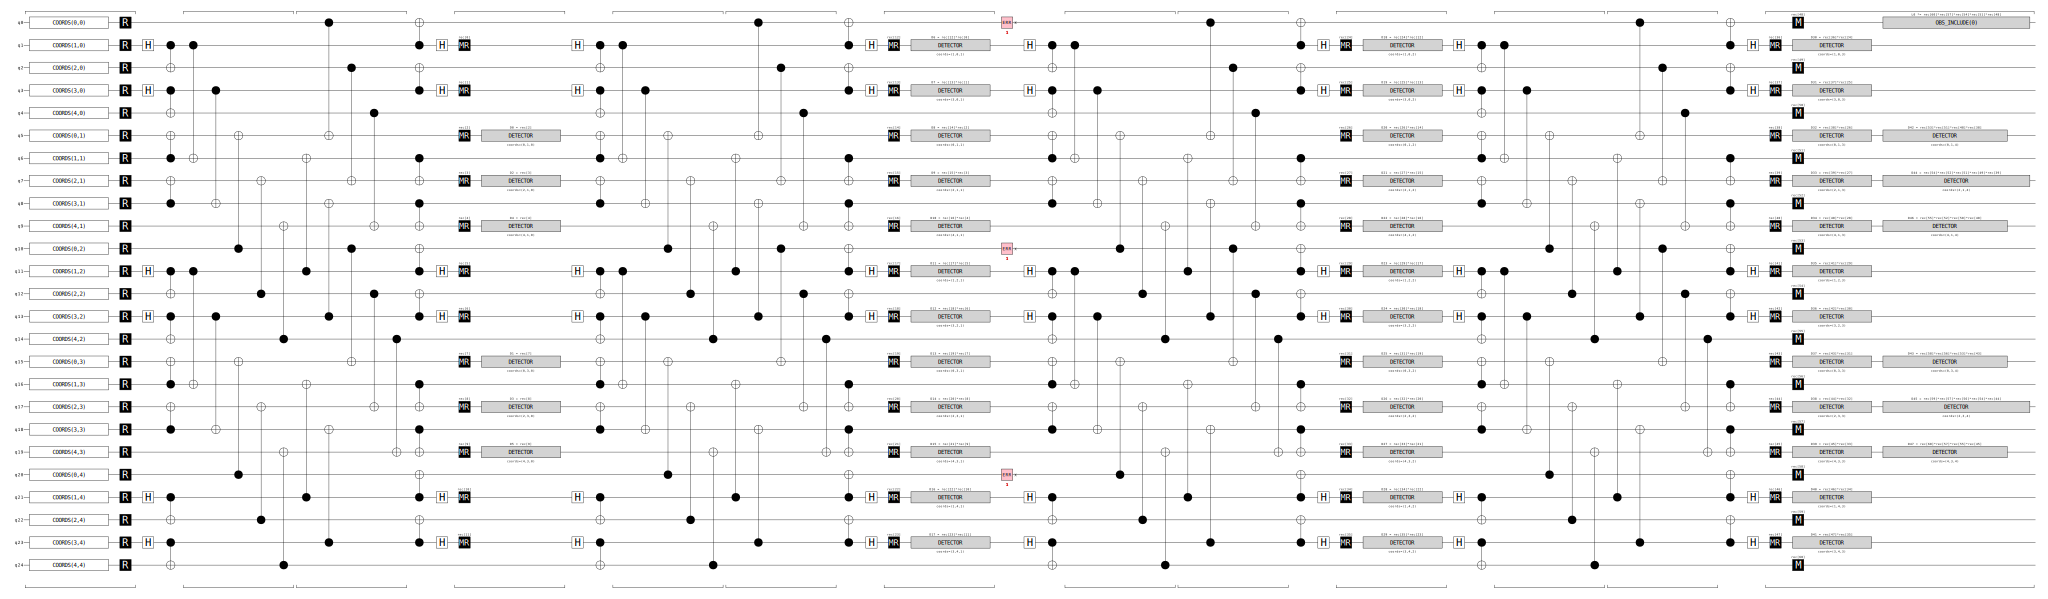

In [4]:
surface_code.diagram("timeline-svg")

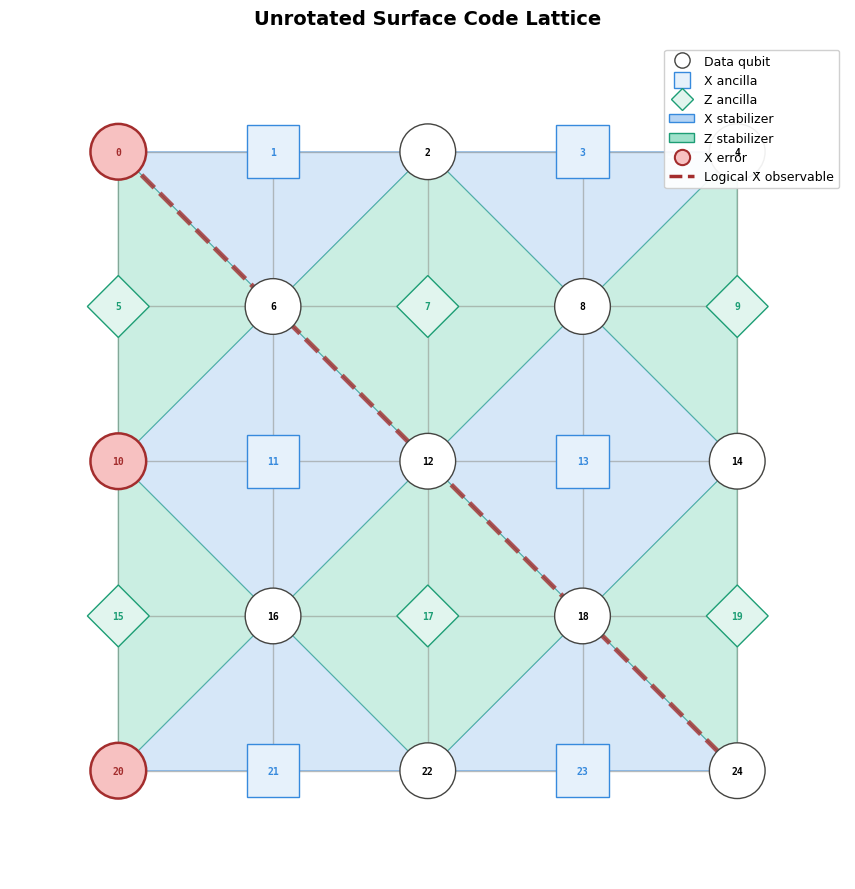

Figure(900x900)


In [5]:
print(plot_surface_code(surface_code))

In [6]:
exec_mwpm(surface_code, 100, 50)


# 1. Compile a sampler from your circuit
sampler = surface_code.compile_detector_sampler()

# 2. Sample detection events and logical observables
# 'separate_observables=True' returns them in two distinct arrays
detectors, observables = sampler.sample(shots=10, separate_observables=True)

# 'observables' is a bit-packed numpy array of shape (shots, num_observables)



--- 100-shot batch decode ---
  Raw observable parities   : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Corrected logical outcomes: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Logical error rate        : 1.00

  Raw = 1 on all shots  → X error flipped the logical Z.
  Corrected = 0         → MWPM identified and cancelled it.


In [7]:
sampler = surface_code.compile_sampler()
samples = sampler.sample(shots=10)
# Number of measurements per sample of the surface code
print(get_data_qubits(3, samples[0]))

for sample in samples:
    string = sample
    data_qubits = get_data_qubits(3, string)
    print_parity(data_qubits, s=5, f=8)

# stab_measurements = []
# for index in range(1, len(one_sample), 2):
#     stab_measurements.append(one_sample[index])
# print(stab_measurements)
# for k in range(0, len(one_sample), 24*5):
#     timeslice = one_sample[k:k+8]
#     print("".join("1" if e else "_" for e in timeslice))

[ True  True  True False  True  True False False  True  True False False
  True]
[ True False False]
ones:8 zeros: 5 parity:1
[False  True False]
ones:4 zeros: 9 parity:1
[False False  True]
ones:5 zeros: 8 parity:1
[False  True False]
ones:7 zeros: 6 parity:1
[False False  True]
ones:5 zeros: 8 parity:1
[False  True False]
ones:3 zeros: 10 parity:1
[ True False False]
ones:7 zeros: 6 parity:1
[False  True False]
ones:4 zeros: 9 parity:1
[ True False False]
ones:5 zeros: 8 parity:1
[ True False False]
ones:6 zeros: 7 parity:1


In [8]:
detector_sampler = surface_code.compile_detector_sampler()
samples = detector_sampler.sample(shots=20)

print(samples[0])
# Number of detectors per sample
print(len(samples[0]))

# stab_measurements = []
# for index in range(1, len(one_sample), 2):
#     stab_measurements.append(one_sample[index])
# print(stab_measurements)


# for k in range(0, len(one_sample), 8):
#     timeslice = one_sample[k:k+8]
#     print("".join("!" if e else "_" for e in timeslice))


[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False]
48
